# Q4: Which categories of problems are most commonly reported in Zurich? 
This question looks at which problem category has the highest number of reports related to it. The anticipated workflow is:

0. Import all packages and functions needed
1. Import the data needed
2. Calculate the number of reports per category
3. Create a table of the result
4. Create a bar chart and a pie chart of the result

## 0. Import block

In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

## 1. Import the data
As no cartographic visualisation is created, the only dataset needed is the spatially joined report dataset.


In [22]:
reports_full_sjoin=import_preprocessed_data("reports_quartiere_sjoin.gpkg")
reports_full_sjoin["report_category"]=reports_full_sjoin["service_code"] #better readability of the notebook + table header

#visual check of the dataset
reports_full_sjoin.info()

The active geometry column of this geodataframe is called 'geometry'.
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73243 entries, 0 to 73242
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   service_request_id  73243 non-null  str           
 1   requested_datetime  73243 non-null  datetime64[ms]
 2   e                   73243 non-null  int32         
 3   n                   73243 non-null  int32         
 4   service_code        73243 non-null  str           
 5   description         73243 non-null  str           
 6   index_right         73243 non-null  int64         
 7   qnr                 73243 non-null  int32         
 8   qname               73243 non-null  str           
 9   knr                 73243 non-null  int32         
 10  kname               73243 non-null  str           
 11  geometry            73243 non-null  geometry      
 12  report_category     7324

## 2. Derive the number of reports per category
Using the newly created 'report_category' column, the number of reports per category is calculated.

In [23]:
# Reports per Category calculation:
nr_reports_per_category=(reports_full_sjoin
                         .groupby("report_category")
                         .size()
                         .reset_index(name="number_of_reports") #makes a column of the resulting numbers
                         .sort_values(by="number_of_reports",ascending=False)) #first sneak peek which category is most common

# first "visualisation" of the results
display(nr_reports_per_category)

,report_category,number_of_reports
0,Abfall/Sammelstelle,27627
7,Signalisation/Lichtsignal,11041
8,Strasse/Trottoir/Platz,9910
5,Grünflächen/Spielplätze,7303
2,Beleuchtung/Uhren,5427
1,Allgemein,4016
4,Graffiti,3809
9,VBZ/ÖV,1898
3,Brunnen/Hydranten,1311
6,Schädlinge,901


## 3. Create an exportable table showing the number of reports per category
The displayed dataframe (above) showed which categories have the most reports. Still, a nicely formatted table is created in this step.

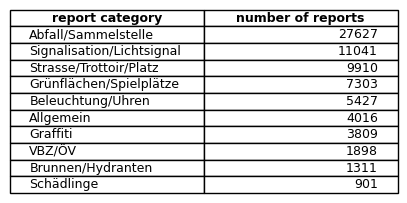

<Figure size 640x480 with 0 Axes>

In [24]:
fig, ax =plt.subplots(figsize=(5,1))
ax.axis("off")

# remove the underline from the column headers
improved_col_headers=[]
for col_header in nr_reports_per_category.columns:
    improved_col_headers.append(col_header.replace("_", " "))

# create the table
overview_table=ax.table(cellText=nr_reports_per_category.values,
         colLabels=improved_col_headers,
         loc="center",
         cellLoc="right")

#further improve aesthetics of the table:
for (row, col), cell in overview_table.get_celld().items():
    #make column titles bold
    if row==0:
        cell.set_text_props(weight="bold")
        continue #to avoid that the text of the column headers are oriented as the text in the cells
    
    # allign text of different columns differently
    elif col==0:
        cell.get_text().set_ha("left") #set_ha=set_horizontal_alignment

export_result_to_png("Q4_table_nrreports_per_category")
plt.show()

plt.clf()


## 4. Visually display this statistics
The table already includes the full answer to the initial question. Still, humans prefer to see such data visualised. Therefore, a bar chart and a pie chart were created to display the results.

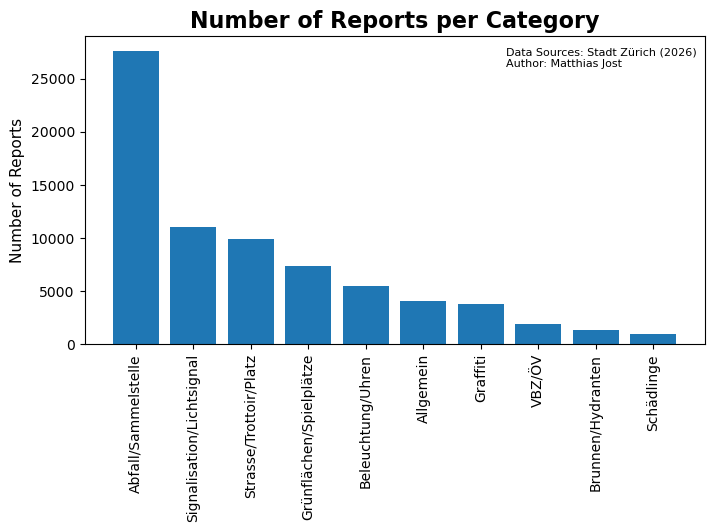

<Figure size 640x480 with 0 Axes>

In [25]:
# Bar Chart
fig, ax = plt.subplots(figsize=(8,4))

ax.bar(x=nr_reports_per_category["report_category"], 
       height=nr_reports_per_category["number_of_reports"], 
       zorder=1)
ax.set_title("Number of Reports per Category", fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Reports", fontsize=11)

#rotate the x_labels:
ax.tick_params(axis="x", rotation=90)

#source and author:
ax.text(0.68,0.9, "Data Sources: Stadt Zürich (2026) \nAuthor: Matthias Jost", transform=ax.transAxes, fontsize=8)

# export and show to plot
export_result_to_png("Q4_barchart_nr_reports_per_category")
plt.show()
plt.clf()

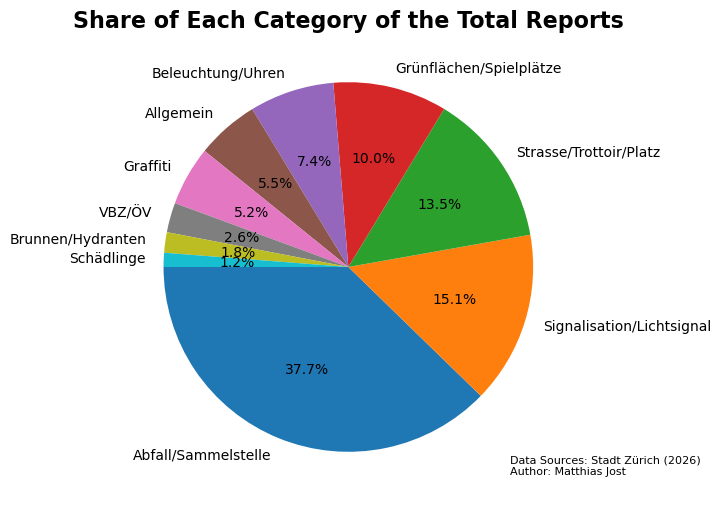

In [26]:
# Pie Chart
fig, ax=plt.subplots(figsize=(6,6))
ax.axis("off")

ax.pie(nr_reports_per_category["number_of_reports"], 
       labels=nr_reports_per_category["report_category"], 
       autopct='%1.1f%%', #adds percentage
       startangle=180) #needed to make the percentage of small categories non-overlapping

ax.set_title("Share of Each Category of the Total Reports", fontsize=16, fontweight="bold")

#Author and Source
ax.text(0.85,0.05, "Data Sources: Stadt Zürich (2026) \nAuthor: Matthias Jost", transform=ax.transAxes, fontsize=8)

#export and plot
export_result_to_png("Q4_piechart_categories")
plt.show()

## 5. Subsequent Question (Q5): What is the most common report category per neighborhood?
Although the initial research question is answered by now, I started wondering whether the category "Abfall/Sammelstelle" (englisch: "Waste/Waste Collection Point") is the most common category in every neighborhood.

In [27]:
# first sort the reports per neighborhood and per category:
reports_per_c_and_n=(reports_full_sjoin
    .groupby(["qname", "report_category"]) #sort by both (basically "sort by each combination")
    .size()
    .reset_index(name="nr_reports")
    .sort_values(by="qname")
)
print(reports_per_c_and_n)#sanity check

           qname            report_category  nr_reports
0      Affoltern        Abfall/Sammelstelle         790
1      Affoltern                  Allgemein         109
2      Affoltern          Beleuchtung/Uhren         247
3      Affoltern          Brunnen/Hydranten          30
4      Affoltern                   Graffiti         133
..           ...                        ...         ...
335  Wollishofen    Grünflächen/Spielplätze         371
336  Wollishofen                 Schädlinge          95
337  Wollishofen  Signalisation/Lichtsignal         413
338  Wollishofen     Strasse/Trottoir/Platz         388
339  Wollishofen                     VBZ/ÖV          51

[340 rows x 3 columns]


To get the maximum category per neighborhood, the idea was to use a for loop. Inside the loop a subset for each neighborhood is created and sorted by number of reports. As the category with the highest number of reports is now the top-row of the subset, it was appended to the newly created list. The retrieved list has then to be converted into a dataframe. Then, it has to be merged with the quartiere gdf.

In [28]:
# get the maximum value per neighborhood: 
highest_report_category_per_neighborhood=[]

for neighborhood_name in reports_per_c_and_n["qname"].unique():
    subset=reports_per_c_and_n[reports_per_c_and_n["qname"]==neighborhood_name]
    subset=subset.sort_values(by="nr_reports", ascending=False)
    highest_report_category_per_neighborhood.append(subset.iloc[0])

# convert the retrieved list into a df
highest_report_category_per_neighborhood=pd.DataFrame(highest_report_category_per_neighborhood)

In [29]:
#merge the newly created dataframe with the quartiere_geodataframe
quartiere_map=import_preprocessed_data("quartiere_map.gpkg")

quartiere_map=quartiere_map.merge(
    highest_report_category_per_neighborhood,
    on="qname",
    how="left")

#visually verify whether the merge worked
quartiere_map.head(2)

The active geometry column of this geodataframe is called 'geometry'.


,qnr,qname,knr,kname,geometry,report_category,nr_reports
0,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315...",Abfall/Sammelstelle,480
1,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291...",Abfall/Sammelstelle,256


## 6. Creating a map answering the subsequent Q5
The derived results are now plotted:

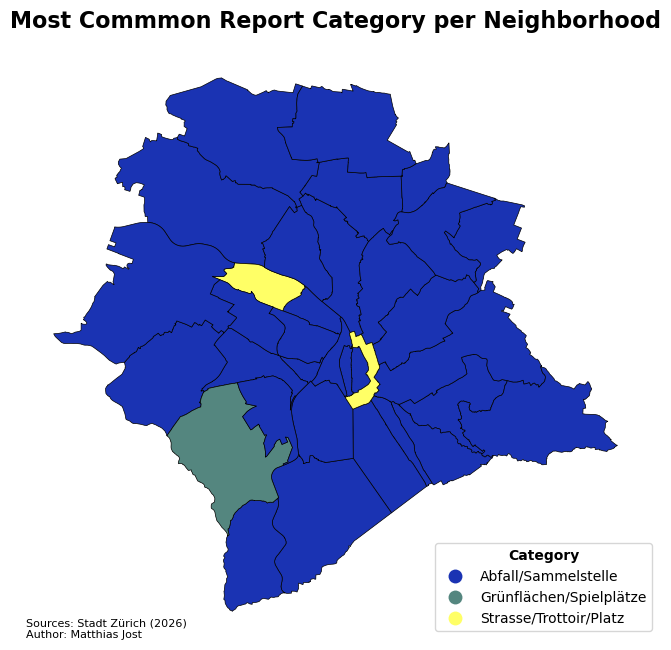

<Figure size 640x480 with 0 Axes>

In [30]:
fig, ax=plt.subplots(figsize=(8,8))

#set the aestetics
ax.axis("off")
ax.set_title("Most Commmon Report Category per Neighborhood", fontsize=16, fontweight="bold")

#plot the layer
quartiere_map.plot(ax=ax, column="report_category",
                   cmap=cmc.imola, legend=True,
                   edgecolor="black", linewidth=0.5, 
                   legend_kwds={"title": "Category",
                                 "loc": "lower left",
                                 "bbox_to_anchor": (0.65, 0.0)})

# modify the legend and add the sources
ax.get_legend().get_title().set_fontweight("bold")
ax.text(0.00, 0.00, "Sources: Stadt Zürich (2026) \nAuthor: Matthias Jost", transform=ax.transAxes, fontsize=8)

#export the resulting map
export_result_to_png("Q5_most_common_category_per_neighborhood")
plt.show()
plt.clf()

As almost 40% of all reports are related to waste or waste management, it is not surprising that in 31 of 34 neighborhoods of the city of Zurich these reports dominate. Interestingly, the category with the second most reports ("Signalisation/Lichtsignal") is never the most reported category in a neighborhood. But the categories with the overall third and fourth most reports are visible on the final map, as the are the most common report category in at least one neighborhood.